In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/cities_magicbricks_rental_prices.csv')

df.head()

Matplotlib is building the font cache; this may take a moment.


,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


In [2]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (7691, 10)

Columns:
['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms', 'balconies', 'furnishing', 'area_rate', 'rent']


In [3]:
df.describe()


,area,beds,bathrooms,balconies,area_rate,rent
count,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03
mean,1106.354180,2.208685,2.137043,0.817319,47.619989,5.479508e+04
std,1197.426843,0.993481,1.027677,1.243361,68.989657,9.742006e+04
min,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000e+03
25%,600.000000,1.000000,1.000000,0.000000,21.000000,1.500000e+04
50%,900.000000,2.000000,2.000000,0.000000,31.000000,2.800000e+04
75%,1300.000000,3.000000,3.000000,2.000000,54.000000,5.700000e+04
max,70000.000000,10.000000,10.000000,10.000000,2586.000000,2.700000e+06


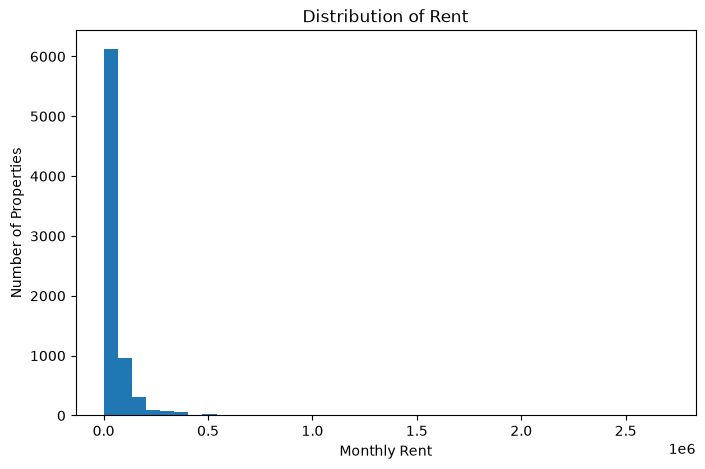

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df['rent'], bins=40)
plt.title('Distribution of Rent')
plt.xlabel('Monthly Rent')
plt.ylabel('Number of Properties')
plt.show()

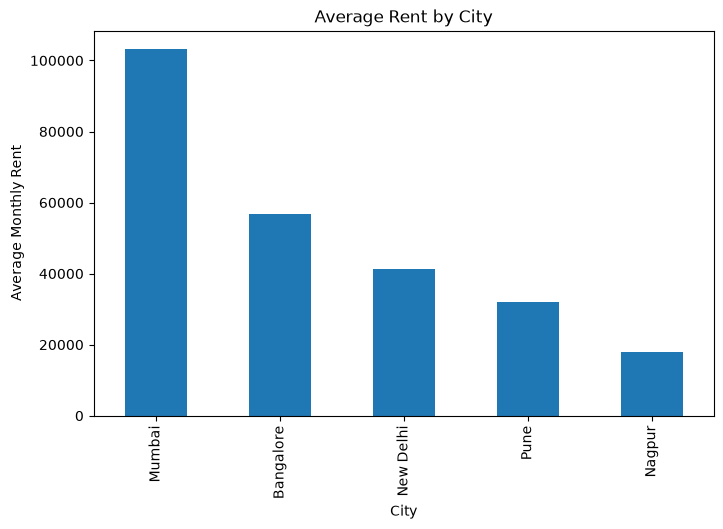

city
Mumbai       103226.538104
Bangalore     56709.260894
New Delhi     41309.158739
Pune          32077.928612
Nagpur        18015.784874
Name: rent, dtype: float64


In [5]:
city_avg = df.groupby('city')['rent'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
city_avg.plot(kind='bar')
plt.title('Average Rent by City')
plt.xlabel('City')
plt.ylabel('Average Monthly Rent')
plt.show()

print(city_avg)

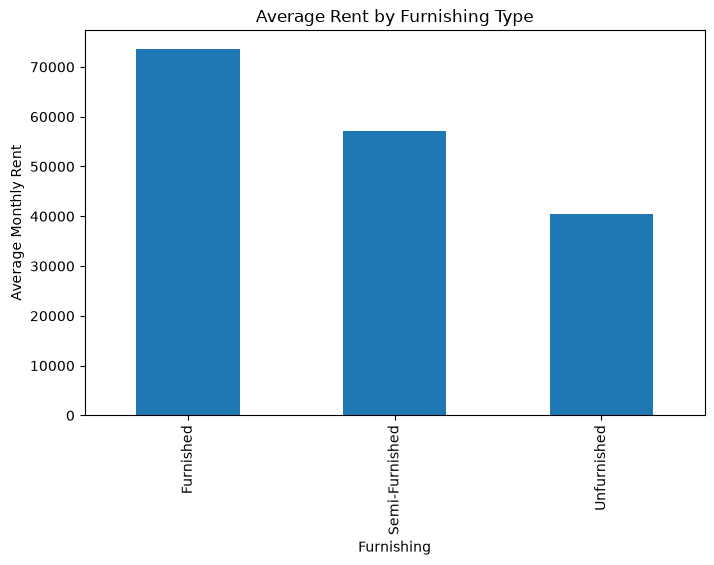

furnishing
Furnished         73651.662086
Semi-Furnished    57112.619603
Unfurnished       40469.801277
Name: rent, dtype: float64


In [6]:
furnishing_avg = df.groupby('furnishing')['rent'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
furnishing_avg.plot(kind='bar')
plt.title('Average Rent by Furnishing Type')
plt.xlabel('Furnishing')
plt.ylabel('Average Monthly Rent')
plt.show()

print(furnishing_avg)

In [7]:
numeric_df = df[['area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent']]
numeric_df.corr()

,area,beds,bathrooms,balconies,area_rate,rent
area,1.000000,0.516329,0.535668,0.296145,0.022209,0.433513
beds,0.516329,1.000000,0.850310,0.418587,0.111820,0.473695
bathrooms,0.535668,0.850310,1.000000,0.442145,0.160051,0.532681
balconies,0.296145,0.418587,0.442145,1.000000,-0.004592,0.179181
area_rate,0.022209,0.111820,0.160051,-0.004592,1.000000,0.507104
rent,0.433513,0.473695,0.532681,0.179181,0.507104,1.000000


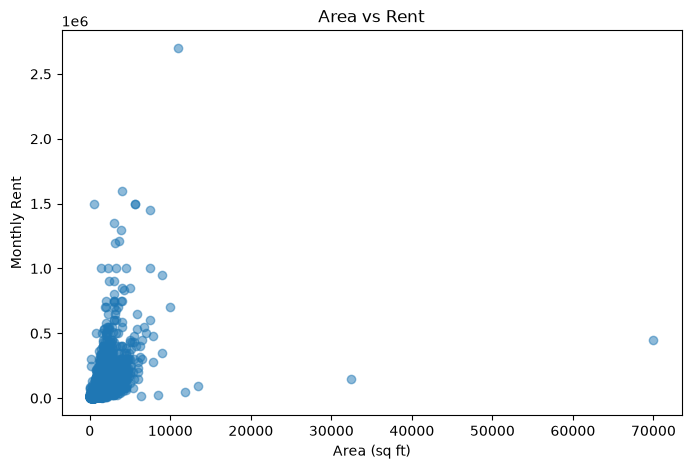

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['rent'], alpha=0.5)
plt.title('Area vs Rent')
plt.xlabel('Area (sq ft)')
plt.ylabel('Monthly Rent')
plt.show()